### Modeling guideline and naming convention

The modeling workflow is organized into four main feature-set variants:

- **V1_TrackA**
- **V1_TrackB**
- **V2_Untuned**
- **V2_Tuned**

These variants are used to compare the **Naive**, **ElasticNet**, **Lasso**, and **CatBoost** approaches under different input representations.

---

### 1. Naive model

The naive benchmark predicts the next-day 24-hour price vector by copying historical price curves:

$$
\hat{\mathbf{y}}_{d}=
\begin{cases}
\mathbf{y}_{d-1}, & \text{if } d \in \{\text{Tue, Wed, Thu, Fri, Sun}\} \\
\mathbf{y}_{d-7}, & \text{if } d \in \{\text{Mon, Sat}\}
\end{cases}
$$

This model does not use engineered predictors and serves as the baseline reference for RMAE.

---

### 2. V1_TrackA

**V1_TrackA** is the first daily feature setup based on the earlier simplified daily matrix.  
One daily row is constructed from the **first hourly row of the day**, and the feature subset follows the **Cecilia's selected variables**.

Used features:

- `load`
- `wind_offshore`
- `wind_onshore`
- `solar`
- `temperature`
- `wind_speed`
- `is_weekend`
- `gas_price`
- `coal_price`
- `price_lag_24h`
- `price_lag_168h`
- `price_rolling_24h`
- `price_rolling_168h`
- `co2_price`
- `is_holiday`
- `is_hol_or_week`
- `net_export`
- `hour_sin`
- `hour_cos`
- `dow_sin`
- `dow_cos`
- `month_sin`
- `month_cos`
- `gas_price_lag_24h`
- `gas_price_lag_168h`
- `coal_price_lag_24h`
- `coal_price_lag_168h`
- `co2_price_lag_24h`
- `renewable_share`
- `fuel_cost_index`
- `dispatchable_gen`
- `demand_supply_gap`
- `is_peak_hour`
- `wind_x_peak`
- `gas_x_peak`
- `solar_x_demand`
- `renewable_share_x_peak`
- `is_crisis_period`
- `is_high_price_regime`
- `residual_load`
- `load_ramp`
- `renewable_ramp`
- `price_volatility_24h`
- `total_wind_forecast`
- `delta_wind_forecast`

---

### 3. V1_TrackB

**V1_TrackB** is the first daily feature setup using a broader feature space.  
It is again based on the simplified daily matrix from the **first hourly row of the day**, but includes nearly all available predictors except explicitly excluded columns.

Excluded columns:

- `timestamp`
- `price`
- `forecast_date`
- `date`
- `actual_wind_offshore`
- `actual_wind_onshore`
- `actual_solar`
- `actual_load`
- `is_negative_price`

Thus, **V1_TrackB** uses all remaining available columns in the daily matrix after these exclusions.

---

### 4. V2_Untuned

**V2_Untuned** is the improved structured daily feature design.  
It is constructed specifically for the **24-hour multi-output forecasting task**.

Instead of keeping only one hourly row per day, the feature matrix is built from:

- **daily scalar features**, included once per day
- **hourly block features**, reshaped into 24 hour-specific columns

This yields a richer day-level representation aligned with the 24-hour target vector.

#### Daily scalar features

- `day_of_week`
- `month`
- `year`
- `is_weekend`
- `is_holiday`
- `is_hol_or_week`
- `gas_price`
- `coal_price`
- `co2_price`
- `gas_price_lag_24h`
- `gas_price_lag_168h`
- `coal_price_lag_24h`
- `coal_price_lag_168h`
- `co2_price_lag_24h`
- `month_sin`
- `month_cos`
- `dow_sin`
- `dow_cos`
- `is_crisis_period`
- `is_high_price_regime`

#### Hourly block features

- `price_lag_24h`
- `price_lag_168h`
- `load`
- `wind_offshore`
- `wind_onshore`
- `solar`
- `temperature`
- `wind_speed`
- `total_wind_forecast`
- `delta_wind_forecast`

These hourly block features are expanded into columns such as:

- `price_lag_24h_h00, ..., price_lag_24h_h23`
- `load_h00, ..., load_h23`
- `solar_h00, ..., solar_h23`

---

### 5. V2_Tuned

**V2_Tuned** uses the same structured feature design as **V2_Untuned**, but with tuned model hyperparameters.

Thus:

$$
\text{V2\_Tuned} = \text{V2\_Untuned features} + \text{hyperparameter tuning}
$$

In the current workflow, this tuning was applied to **CatBoost**, while the feature matrix remained identical to **V2_Untuned**.

---

### 6. Relation between the variants

In summary:

- **V1_TrackA**: simplified daily matrix + Cecilia's selected features
- **V1_TrackB**: simplified daily matrix + broader feature set
- **V2_Untuned**: structured daily matrix with scalar and hourly block features
- **V2_Tuned**: same structured feature matrix as V2_Untuned, but with tuned model parameters

This naming convention is used consistently throughout the model comparison.

In [201]:
# Import core libraries 
# =========================================================
import pandas as pd
import numpy as np

# =========================================================
# Import libraries for visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# Import sklearn tools for baseline modeling
# ElasticNet = linear regularized baseline
# MultiOutputRegressor = wraps ElasticNet for 24-output prediction
# Pipeline = combines scaling + model cleanly
# StandardScaler = scales features for linear models
# mean_absolute_error = evaluation metric
# =========================================================
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# =========================================================
# Import Optuna for later hyperparameter tuning
# =========================================================
import optuna

# =========================================================
# Set plotting style for cleaner notebook visuals
# =========================================================
sns.set_style(
    style="darkgrid",
    rc={"axes.facecolor": "white", "grid.color": ".8"}
)

# =========================================================
# Set pandas display options for easier inspection
# =========================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [202]:
# Load the dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic structure
print("Shape:", df.shape)
display(df.head(2))
print(df.columns.tolist())

Shape: (62544, 60)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,2019-01-16 00:00:00,29.23,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,22.004999,83.0,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.5,8970.75,3558.75,30280.00,0.0,55014.00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.5
1,2019-01-16 01:00:00,29.26,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,22.004999,83.0,35.82,7.24,44.926667,41.836190,22.81,False,False,67991.75,11379.0,13050.75,4994.5,8959.00,3603.00,29191.25,0.0,52838.75,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.449812,46.402999,27004.25,-15541.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21866.50,-1845.00,-835.25,10.008918,30583.50,510.5


['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_fo

### 3. Data checks

In [203]:
# Check the date range of the dataset
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

# Check the number of rows and columns
print("Shape:", df.shape)

# Show data types of all columns
display(df.dtypes)

# Show missing values per column, sorted from highest to lowest
display(df.isna().sum().sort_values(ascending=False))

Date range: 2019-01-16 00:00:00 to 2026-03-05 23:00:00
Shape: (62544, 60)


timestamp                 datetime64[ns]
price                            float64
load                             float64
wind_offshore                    float64
wind_onshore                     float64
solar                            float64
hour                             float64
day_of_week                      float64
month                            float64
temperature                      float64
wind_speed                       float64
is_weekend                          bool
gas_price                        float64
coal_price                       float64
price_lag_24h                    float64
price_lag_168h                   float64
price_rolling_24h                float64
price_rolling_168h               float64
co2_price                        float64
is_holiday                          bool
is_hol_or_week                      bool
total_generation                 float64
net_export                       float64
coal_generation                  float64
gas_generation  

timestamp                 0
price                     0
dow_sin                   0
dow_cos                   0
month_sin                 0
month_cos                 0
gas_price_lag_24h         0
gas_price_lag_168h        0
coal_price_lag_24h        0
coal_price_lag_168h       0
co2_price_lag_24h         0
renewable_share           0
fuel_cost_index           0
dispatchable_gen          0
demand_supply_gap         0
is_peak_hour              0
wind_x_peak               0
gas_x_peak                0
solar_x_demand            0
renewable_share_x_peak    0
is_crisis_period          0
is_high_price_regime      0
is_negative_price         0
year                      0
residual_load             0
load_ramp                 0
renewable_ramp            0
price_volatility_24h      0
total_wind_forecast       0
hour_cos                  0
hour_sin                  0
actual_load               0
price_lag_24h             0
load                      0
wind_offshore             0
wind_onshore        

In [204]:
# Check whether the timestamp column is strictly increasing
print("Timestamp sorted:", df["timestamp"].is_monotonic_increasing)

# Check the most common time differences between consecutive rows
display(df["timestamp"].diff().value_counts().head())

Timestamp sorted: True


timestamp
0 days 01:00:00    62543
Name: count, dtype: int64

### 4. Inspect the existing structure for daily forecasting

In [205]:
# Check how many rows belong to each calendar day using the timestamp column directly
rows_per_day = df.groupby(df["timestamp"].dt.date).size()

# Show how many days have 24 rows and whether any days are incomplete
display(rows_per_day.value_counts().sort_index())

24    2606
Name: count, dtype: int64

###  5,6. Check duplicate day-hour combinations

In [206]:
# Recreate helper columns directly from the timestamp
df["forecast_date"] = df["timestamp"].dt.floor("D")
df["hour"] = df["timestamp"].dt.hour

# Count duplicate combinations of forecast_date and hour
duplicate_count = df.duplicated(subset=["forecast_date", "hour"]).sum()
print("Number of duplicate day-hour rows:", duplicate_count)

# Show all duplicated rows, if any exist
duplicate_rows = df[df.duplicated(subset=["forecast_date", "hour"], keep=False)].copy()

# Sort for easier inspection
duplicate_rows = duplicate_rows.sort_values(["forecast_date", "hour", "timestamp"])

# Display a compact view
display(duplicate_rows[["timestamp", "forecast_date", "hour", "price"]].head(50))

Number of duplicate day-hour rows: 0


,timestamp,forecast_date,hour,price


### 7. Create the 24-hour target matrix
this converts hourly prices into one row per day. each row now has 24 target values
this is Y for multi-output forecasting


In [207]:
# Create a daily datetime column for reshaping
df["forecast_date"] = df["timestamp"].dt.floor("D")

# Reshape hourly prices into one row per day and 24 price columns
target_wide = df.pivot(index="forecast_date", columns="hour", values="price")

# Rename the target columns clearly as price_h00 to price_h23
target_wide.columns = [f"price_h{hour:02d}" for hour in target_wide.columns]

# Sort the target matrix by day
target_wide = target_wide.sort_index()

# Show the result
print(target_wide.shape)
display(target_wide.head())

(2606, 24)


,price_h00,price_h01,price_h02,price_h03,price_h04,price_h05,price_h06,price_h07,price_h08,price_h09,price_h10,price_h11,price_h12,price_h13,price_h14,price_h15,price_h16,price_h17,price_h18,price_h19,price_h20,price_h21,price_h22,price_h23
forecast_date,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-16,29.23,29.26,32.64,32.41,33.06,33.22,46.63,53.80,55.73,53.83,54.22,54.92,53.65,52.69,53.55,53.72,54.83,54.01,52.67,50.92,39.81,39.29,39.91,30.77
2019-01-17,26.35,25.23,22.77,24.02,25.63,28.06,35.38,46.04,49.96,50.56,46.10,46.02,43.94,46.64,55.00,55.90,57.43,58.72,55.06,53.85,49.52,42.35,42.44,41.11
2019-01-18,42.26,40.91,43.77,45.05,47.89,49.79,54.77,73.08,76.86,74.32,70.51,69.02,68.94,65.27,67.44,68.14,69.00,75.04,76.13,72.46,61.83,59.24,56.70,53.16
2019-01-19,52.47,53.18,54.73,51.15,52.25,50.93,49.04,50.56,55.71,56.62,63.13,57.33,55.26,54.38,52.55,55.41,62.93,67.15,68.91,57.37,54.61,52.32,51.53,49.80
2019-01-20,47.74,47.01,48.80,48.90,49.63,49.53,46.69,46.76,50.88,52.38,50.07,49.33,48.98,47.40,53.20,55.39,58.02,66.68,69.43,69.75,67.83,57.37,59.56,52.07


In [208]:
# Create a temporary calendar-day column for reshaping
df["forecast_date"] = df["timestamp"].dt.date

# Reshape hourly prices into one row per day and 24 price columns
target_wide = df.pivot(index="forecast_date", columns="hour", values="price")

# Rename the target columns clearly as price_h00 to price_h23
target_wide.columns = [f"price_h{hour:02d}" for hour in target_wide.columns]

# Sort the target matrix by day
target_wide = target_wide.sort_index()

# Show the result
print(target_wide.shape)
display(target_wide.head())

(2606, 24)


,price_h00,price_h01,price_h02,price_h03,price_h04,price_h05,price_h06,price_h07,price_h08,price_h09,price_h10,price_h11,price_h12,price_h13,price_h14,price_h15,price_h16,price_h17,price_h18,price_h19,price_h20,price_h21,price_h22,price_h23
forecast_date,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-16,29.23,29.26,32.64,32.41,33.06,33.22,46.63,53.80,55.73,53.83,54.22,54.92,53.65,52.69,53.55,53.72,54.83,54.01,52.67,50.92,39.81,39.29,39.91,30.77
2019-01-17,26.35,25.23,22.77,24.02,25.63,28.06,35.38,46.04,49.96,50.56,46.10,46.02,43.94,46.64,55.00,55.90,57.43,58.72,55.06,53.85,49.52,42.35,42.44,41.11
2019-01-18,42.26,40.91,43.77,45.05,47.89,49.79,54.77,73.08,76.86,74.32,70.51,69.02,68.94,65.27,67.44,68.14,69.00,75.04,76.13,72.46,61.83,59.24,56.70,53.16
2019-01-19,52.47,53.18,54.73,51.15,52.25,50.93,49.04,50.56,55.71,56.62,63.13,57.33,55.26,54.38,52.55,55.41,62.93,67.15,68.91,57.37,54.61,52.32,51.53,49.80
2019-01-20,47.74,47.01,48.80,48.90,49.63,49.53,46.69,46.76,50.88,52.38,50.07,49.33,48.98,47.40,53.20,55.39,58.02,66.68,69.43,69.75,67.83,57.37,59.56,52.07


### 8. Create the daily feature matrix

In [209]:
# Keep only the first hourly row of each day as the base daily feature row
X_daily = df.groupby("forecast_date").first().copy()

# Drop the raw hourly target column because price belongs in Y, not in X
X_daily = X_daily.drop(columns=["price"], errors="ignore")

# Remove timestamp because it is no longer needed after daily grouping
X_daily = X_daily.drop(columns=["timestamp"], errors="ignore")

# Show the shape and first rows
print(X_daily.shape)
display(X_daily.head())

(2606, 58)


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
forecast_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-16,54295.00,4647.00,26771.75,0.0,0,2.0,1.0,4.9125,36.267860,False,22.004999,83.000000,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.50,8970.75,3558.75,30280.00,0.0,55014.00,0.0,1.0,0.974928,-0.222521,0.5,0.866025,22.000000,21.719999,82.500000,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.50
2019-01-17,54529.00,5002.25,28126.25,0.0,0,3.0,1.0,3.6125,33.579308,False,22.995001,83.400002,29.23,46.48,45.078750,42.273095,23.55,False,False,69125.75,12636.0,13610.50,4820.25,8880.25,4691.50,29135.75,0.0,56023.00,0.0,1.0,0.433884,-0.900969,0.5,0.866025,22.004999,21.674999,83.000000,82.300003,22.81,0.479250,47.157001,27311.00,-14596.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21400.50,-2521.75,-387.50,10.399351,33128.50,1709.75
2019-01-18,55446.75,2756.00,20091.25,0.0,0,4.0,1.0,0.2750,32.251987,False,22.605000,83.199997,26.35,47.84,43.499583,38.811786,23.55,False,False,68646.75,13169.0,21408.25,6091.25,9223.00,3058.25,20985.25,0.0,56387.00,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,22.995001,22.254999,83.400002,82.550003,23.55,0.332823,46.842999,36722.50,-13200.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,32599.50,-2029.25,-2876.75,11.202187,22847.25,-10281.25
2019-01-19,53091.25,906.50,4759.00,0.0,0,5.0,1.0,-2.5250,21.034130,True,22.605000,83.199997,42.26,47.24,62.157917,40.563869,23.55,False,True,61726.25,7986.0,30257.75,7311.25,9486.00,1167.50,5239.75,0.0,55144.25,0.0,1.0,-0.974928,-0.222521,0.5,0.866025,22.605000,22.254999,83.199997,82.550003,23.55,0.091784,46.842999,47055.00,-8635.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,47425.75,-2847.50,-219.50,11.306608,5665.50,-17181.75
2019-01-20,49703.00,581.75,4734.75,0.0,0,6.0,1.0,-5.6500,14.905724,True,22.605000,83.199997,52.47,23.35,55.191250,42.761726,23.55,False,True,58219.50,10363.0,26733.25,7119.00,9513.00,880.75,5802.50,0.0,50636.25,0.0,1.0,-0.781831,0.623490,0.5,0.866025,22.605000,22.254999,83.199997,82.550003,23.55,0.091318,46.842999,43365.25,-8516.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,44386.50,-2093.75,-1299.00,5.464132,5316.50,-349.00


### 9. Align the daily feature matrix and target matrix 
This makes sure X and Y refer to the same forecast days after this, we have the basic daily modeling tables ready

In [210]:
# Keep only dates that exist in both X and Y
common_dates = X_daily.index.intersection(target_wide.index)

# Align X and Y to the same daily index
X_daily = X_daily.loc[common_dates].sort_index()
Y_daily = target_wide.loc[common_dates].sort_index()

# Check the final shapes
print("X_daily shape:", X_daily.shape)
print("Y_daily shape:", Y_daily.shape)

# Check whether both indices are identical
print("Indices match:", X_daily.index.equals(Y_daily.index))

X_daily shape: (2606, 58)
Y_daily shape: (2606, 24)
Indices match: True


### 10. Convert the daily index to datetime

In [211]:
# Convert the X index from Python date objects to pandas datetime
X_daily.index = pd.to_datetime(X_daily.index)

# Convert the Y index from Python date objects to pandas datetime
Y_daily.index = pd.to_datetime(Y_daily.index)

### 11. Train-validation-test split

In [212]:
# Split feature data into train, validation, and test sets
X_train = X_daily[X_daily.index < "2025-01-01"].copy()
X_val = X_daily[(X_daily.index >= "2025-01-01") & (X_daily.index < "2025-07-01")].copy()
X_test = X_daily[X_daily.index >= "2025-07-01"].copy()

# Split target data into train, validation, and test sets
Y_train = Y_daily[Y_daily.index < "2025-01-01"].copy()
Y_val = Y_daily[(Y_daily.index >= "2025-01-01") & (Y_daily.index < "2025-07-01")].copy()
Y_test = Y_daily[Y_daily.index >= "2025-07-01"].copy()

# Print the shapes of all splits
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

X_train: (2177, 58)
X_val: (181, 58)
X_test: (248, 58)
Y_train: (2177, 24)
Y_val: (181, 24)
Y_test: (248, 24)


### 11b. Visual check of the train-validation-test split

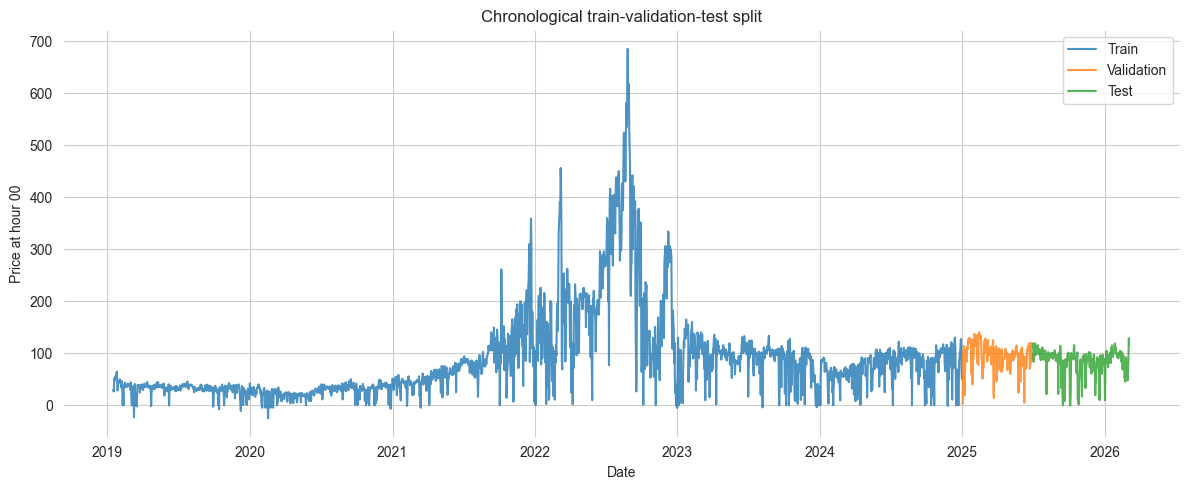

In [213]:
# Create a daily series from the first target hour only for plotting the split over time
plot_series = Y_daily["price_h00"].copy()

# Create the figure
plt.figure(figsize=(12, 5))

# Plot the training period
plt.plot(plot_series.loc[X_train.index], label="Train", alpha=0.8)

# Plot the validation period
plt.plot(plot_series.loc[X_val.index], label="Validation", alpha=0.8)

# Plot the test period
plt.plot(plot_series.loc[X_test.index], label="Test", alpha=0.8)

# Add labels and title
plt.xlabel("Date")
plt.ylabel("Price at hour 00")
plt.title("Chronological train-validation-test split")

# Show legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

### 12. Create training sample weights

In [214]:
# Create a weight series with default weight 1.0 for all training days
train_weights = pd.Series(1.0, index=X_train.index)

# Downweight the pre-crisis period
train_weights.loc[(train_weights.index >= "2019-01-01") & (train_weights.index < "2021-01-01")] = 0.6

# Downweight the crisis period more strongly
train_weights.loc[(train_weights.index >= "2021-01-01") & (train_weights.index < "2023-01-01")] = 0.3

# Keep full weight for the post-crisis period inside training
train_weights.loc[(train_weights.index >= "2023-01-01") & (train_weights.index < "2025-01-01")] = 1.0

# Show how many days fall into each weight group
display(train_weights.value_counts().sort_index())

# Show the first rows
display(train_weights.head())

0.3    730
0.6    716
1.0    731
Name: count, dtype: int64

forecast_date
2019-01-16    0.6
2019-01-17    0.6
2019-01-18    0.6
2019-01-19    0.6
2019-01-20    0.6
dtype: float64

### 13. Build the naive baseline

$$
    \mathbf{y}_{d}=
\begin{cases}
\mathbf{y}_{d-1}, & \text{if } d \in \{\text{Tue, Wed, Thu, Fri, Sun}\} \\
\mathbf{y}_{d-7}, & \text{if } d \in \{\text{Mon, Sat}\}
\end{cases}
$$

In [215]:
# Define a function for the naive daily 24-hour forecast
def predict_price_lag_daily(y_daily):
    # Create an empty DataFrame with the same index and columns as the target
    y_pred = pd.DataFrame(index=y_daily.index, columns=y_daily.columns, dtype=float)

    # Loop over each forecast day
    for day in y_daily.index:
        # Get the weekday of the forecast day
        day_of_week = day.dayofweek

        # Use D-1 for Tue, Wed, Thu, Fri, Sun
        if day_of_week in {1, 2, 3, 4, 6}:
            ref_day = day - pd.Timedelta(days=1)
        # Use D-7 for Mon and Sat
        else:
            ref_day = day - pd.Timedelta(days=7)

        # Copy the full 24-hour curve if the reference day exists
        if ref_day in y_daily.index:
            y_pred.loc[day] = y_daily.loc[ref_day].values

    # Return the naive prediction matrix
    return y_pred

# Create naive predictions for all available days
Y_pred_naive = predict_price_lag_daily(Y_daily)

### 13b. Plot actual vs. naive forecast for one example day

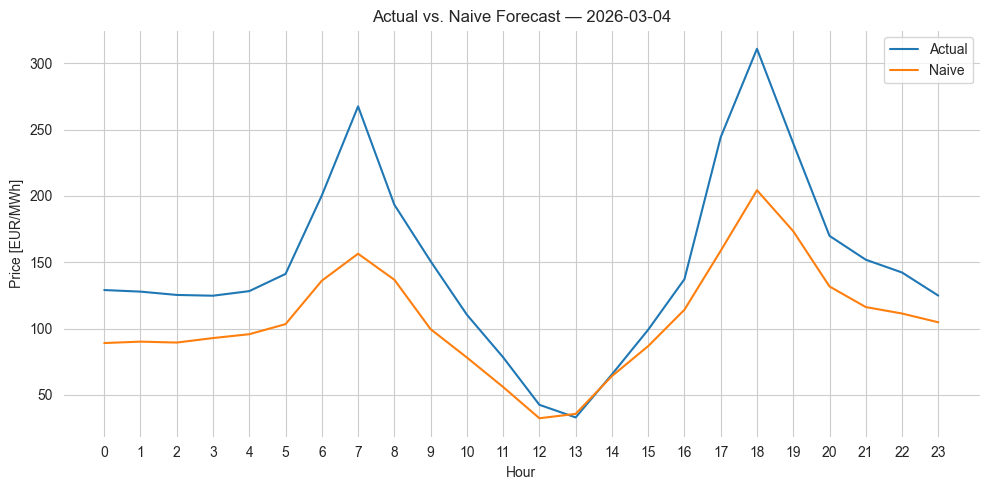

In [216]:
# Select one day for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual and naive values for that day
plot_df = pd.DataFrame({
    "actual": Y_daily.loc[day].values,
    "naive": Y_pred_naive.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual and naive hourly prices
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual")
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. Naive Forecast — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 14. Define the evaluation metrics
mae_24 measures hourly forecast error over all 24 outputs
dae measures how well the daily average price level is captured
rmae compares a model against the naive baseline

$$
\mathrm{MAE} = \frac{1}{N \cdot 24} \sum_{d=1}^{N} \sum_{h=1}^{24} \left| y_{d,h} - \hat{y}_{d,h} \right|
$$

$$
\mathrm{DAE} = \frac{1}{N} \sum_{d=1}^{N} \left| \frac{1}{24}\sum_{h=1}^{24} y_{d,h} - \frac{1}{24}\sum_{h=1}^{24} \hat{y}_{d,h} \right|
$$

$$
\mathrm{RMAE} = \frac{\mathrm{MAE}_{\mathrm{model}}}{\mathrm{MAE}_{\mathrm{naive}}}
$$

In [217]:
# Define MAE over all predicted hourly values
def mae_24(y_true, y_pred):
    # Flatten both matrices and compute the mean absolute error
    return mean_absolute_error(y_true.values.ravel(), y_pred.values.ravel())

# Define DAE based on the daily average price level
def dae(y_true, y_pred):
    # Compute the daily mean price from the 24 hourly values
    true_daily_mean = y_true.mean(axis=1)
    pred_daily_mean = y_pred.mean(axis=1)
    
    # Compute the mean absolute difference between daily average prices
    return np.mean(np.abs(true_daily_mean - pred_daily_mean))

# Define RMAE relative to the naive baseline
def rmae(model_mae, naive_mae):
    # Compare model MAE to naive MAE
    return model_mae / naive_mae

### 15. Evaluate the naive baseline on validation and test

In [218]:
# Create naive predictions for the validation period
Y_val_naive = Y_pred_naive.loc[Y_val.index].copy()

# Create naive predictions for the test period
Y_test_naive = Y_pred_naive.loc[Y_test.index].copy()

# Compute naive validation metrics
naive_val_mae = mae_24(Y_val, Y_val_naive)
naive_val_dae = dae(Y_val, Y_val_naive)

# Compute naive test metrics
naive_test_mae = mae_24(Y_test, Y_test_naive)
naive_test_dae = dae(Y_test, Y_test_naive)

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4164
Naive validation DAE: 22.57
Naive test MAE: 23.3474
Naive test DAE: 18.8407


--------------------------------------------------------------------------------

### 16. Define the feature sets for modeling

#### Track A — Cecilia-style selected features

In [219]:
# Define Cecilia-style selected features
feature_cols_A = [
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "temperature",
    "wind_speed",
    "is_weekend",
    "gas_price",
    "coal_price",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_24h",
    "price_rolling_168h",
    "co2_price",
    "is_holiday",
    "is_hol_or_week",
    "net_export",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h",
    "renewable_share",
    "fuel_cost_index",
    "dispatchable_gen",
    "demand_supply_gap",
    "is_peak_hour",
    "wind_x_peak",
    "gas_x_peak",
    "solar_x_demand",
    "renewable_share_x_peak",
    "is_crisis_period",
    "is_high_price_regime",
    "residual_load",
    "load_ramp",
    "renewable_ramp",
    "price_volatility_24h",
    "total_wind_forecast",
    "delta_wind_forecast"
]

# Create the Cecilia-style feature matrices
X_train_A = X_train[feature_cols_A].copy()
X_val_A = X_val[feature_cols_A].copy()
X_test_A = X_test[feature_cols_A].copy()

# Show the number of selected features
print("Track A - number of features:", len(feature_cols_A))
print(feature_cols_A)

Track A - number of features: 45
['load', 'wind_offshore', 'wind_onshore', 'solar', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'net_export', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_forecast']


#### Track B — Full feature set except excluded columns

In [220]:
# Define columns that should not be used as model features
exclude_cols = [
    "timestamp",
    "price",
    "forecast_date",
    "date",
    "actual_wind_offshore",
    "actual_wind_onshore",
    "actual_solar",
    "actual_load",
    "is_negative_price"
]

# Define the broader feature set from all remaining available columns
feature_cols_B = [col for col in X_daily.columns if col not in exclude_cols]

# Create the full-feature matrices
X_train_B = X_train[feature_cols_B].copy()
X_val_B = X_val[feature_cols_B].copy()
X_test_B = X_test[feature_cols_B].copy()

# Show the number of selected features
print("Track B - number of features:", len(feature_cols_B))
print(feature_cols_B)

Track B - number of features: 53
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_forecast']


### 18. Build the ElasticNet baseline

#### Track A — Cecilia-style selected features

In [221]:
# Build a pipeline with feature scaling and ElasticNet
elasticnet_A = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42)
    ))
])

# Fit the ElasticNet model on Track A using training data and sample weights
elasticnet_A.fit(X_train_A, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_enet_A = pd.DataFrame(
    elasticnet_A.predict(X_val_A),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_enet_A = pd.DataFrame(
    elasticnet_A.predict(X_test_A),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_enet_A.shape)
print("Test prediction shape:", Y_test_pred_enet_A.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 19. Evaluate the ElasticNet baseline

#### Track A — Cecilia-style selected features

In [222]:
# Compute validation metrics for ElasticNet Track A
enet_A_val_mae = mae_24(Y_val, Y_val_pred_enet_A)
enet_A_val_dae = dae(Y_val, Y_val_pred_enet_A)
enet_A_val_rmae = rmae(enet_A_val_mae, naive_val_mae)

# Compute test metrics for ElasticNet Track A
enet_A_test_mae = mae_24(Y_test, Y_test_pred_enet_A)
enet_A_test_dae = dae(Y_test, Y_test_pred_enet_A)
enet_A_test_rmae = rmae(enet_A_test_mae, naive_test_mae)

# Print validation results
print("ElasticNet Track A - validation MAE:", round(enet_A_val_mae, 4))
print("ElasticNet Track A - validation DAE:", round(enet_A_val_dae, 4))
print("ElasticNet Track A - validation RMAE:", round(enet_A_val_rmae, 4))

# Print test results
print("ElasticNet Track A - test MAE:", round(enet_A_test_mae, 4))
print("ElasticNet Track A - test DAE:", round(enet_A_test_dae, 4))
print("ElasticNet Track A - test RMAE:", round(enet_A_test_rmae, 4))

ElasticNet Track A - validation MAE: 23.5289
ElasticNet Track A - validation DAE: 15.9263
ElasticNet Track A - validation RMAE: 0.828
ElasticNet Track A - test MAE: 19.3831
ElasticNet Track A - test DAE: 13.7867
ElasticNet Track A - test RMAE: 0.8302


### 20. Build the ElasticNet baseline

#### Track B — Full feature set

In [223]:
# Build a pipeline with feature scaling and ElasticNet
elasticnet_B = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42)
    ))
])

# Fit the ElasticNet model on Track B using training data and sample weights
elasticnet_B.fit(X_train_B, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_enet_B = pd.DataFrame(
    elasticnet_B.predict(X_val_B),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_enet_B = pd.DataFrame(
    elasticnet_B.predict(X_test_B),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_enet_B.shape)
print("Test prediction shape:", Y_test_pred_enet_B.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 21. Evaluate the ElasticNet baseline

#### Track B — Full feature set

In [224]:
# Compute validation metrics for ElasticNet Track B
enet_B_val_mae = mae_24(Y_val, Y_val_pred_enet_B)
enet_B_val_dae = dae(Y_val, Y_val_pred_enet_B)
enet_B_val_rmae = rmae(enet_B_val_mae, naive_val_mae)

# Compute test metrics for ElasticNet Track B
enet_B_test_mae = mae_24(Y_test, Y_test_pred_enet_B)
enet_B_test_dae = dae(Y_test, Y_test_pred_enet_B)
enet_B_test_rmae = rmae(enet_B_test_mae, naive_test_mae)

# Print validation results
print("ElasticNet Track B - validation MAE:", round(enet_B_val_mae, 4))
print("ElasticNet Track B - validation DAE:", round(enet_B_val_dae, 4))
print("ElasticNet Track B - validation RMAE:", round(enet_B_val_rmae, 4))

# Print test results
print("ElasticNet Track B - test MAE:", round(enet_B_test_mae, 4))
print("ElasticNet Track B - test DAE:", round(enet_B_test_dae, 4))
print("ElasticNet Track B - test RMAE:", round(enet_B_test_rmae, 4))

ElasticNet Track B - validation MAE: 23.0225
ElasticNet Track B - validation DAE: 15.8108
ElasticNet Track B - validation RMAE: 0.8102
ElasticNet Track B - test MAE: 19.2775
ElasticNet Track B - test DAE: 13.9064
ElasticNet Track B - test RMAE: 0.8257


### 22. Compare the baseline results

In [225]:
# Create a summary table with validation and test results for all current models
results_baselines = pd.DataFrame({
    "model": ["Naive", "ElasticNet_A", "ElasticNet_B"],
    "val_MAE": [naive_val_mae, enet_A_val_mae, enet_B_val_mae],
    "val_DAE": [naive_val_dae, enet_A_val_dae, enet_B_val_dae],
    "val_RMAE": [1.0, enet_A_val_rmae, enet_B_val_rmae],
    "test_MAE": [naive_test_mae, enet_A_test_mae, enet_B_test_mae],
    "test_DAE": [naive_test_dae, enet_A_test_dae, enet_B_test_dae],
    "test_RMAE": [1.0, enet_A_test_rmae, enet_B_test_rmae]
})

# Round the values for cleaner display
results_baselines = results_baselines.round(4)

# Display the comparison table
display(results_baselines)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,Naive,28.4164,22.5700,1.0000,23.3474,18.8407,1.0000
1,ElasticNet_A,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
2,ElasticNet_B,23.0225,15.8108,0.8102,19.2775,13.9064,0.8257


### 22b. Plot actual vs. ElasticNet forecast for one example day

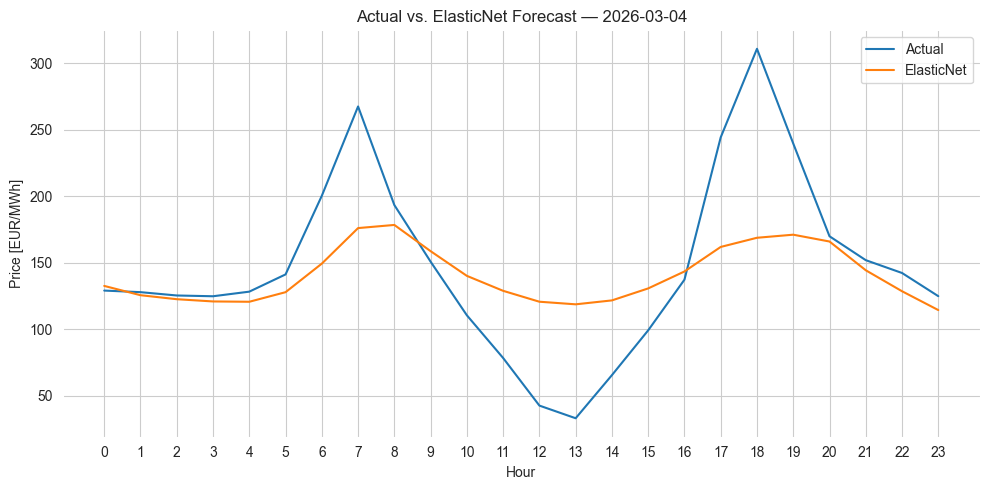

In [226]:
# Select one day for visual comparison
day = "2026-03-04"

# Choose which prediction to plot
y_pred_plot = Y_test_pred_enet_A.copy()

# Create a DataFrame with actual and predicted values for that day
plot_df = pd.DataFrame({
    "actual": Y_test.loc[day].values,
    "elasticnet": y_pred_plot.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual and predicted hourly prices
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual")
plt.plot(plot_df["hour"], plot_df["elasticnet"], label="ElasticNet")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. ElasticNet Forecast — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 23. Simple hyperparameter tuning for ElasticNet

#### Track A — Cecilia-style selected features

In [227]:
# Define a small grid of ElasticNet hyperparameters
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0]
l1_ratio_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

# Create an empty list to store tuning results
tuning_results_A = []

# Loop over all parameter combinations
for alpha in alpha_grid:
    for l1_ratio in l1_ratio_grid:
        
        # Build the ElasticNet pipeline for the current parameter combination
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(
                ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
            ))
        ])
        
        # Fit the model on the training data with sample weights
        model.fit(X_train_A, Y_train, model__sample_weight=train_weights)
        
        # Predict on the validation set
        Y_val_pred = pd.DataFrame(
            model.predict(X_val_A),
            index=Y_val.index,
            columns=Y_val.columns
        )
        
        # Compute validation metrics
        val_mae = mae_24(Y_val, Y_val_pred)
        val_dae = dae(Y_val, Y_val_pred)
        val_rmae = rmae(val_mae, naive_val_mae)
        
        # Store the results
        tuning_results_A.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "val_MAE": val_mae,
            "val_DAE": val_dae,
            "val_RMAE": val_rmae
        })

# Convert results to a DataFrame
tuning_results_A = pd.DataFrame(tuning_results_A)

# Sort by validation MAE from best to worst
tuning_results_A = tuning_results_A.sort_values("val_MAE").reset_index(drop=True)

# Show the best combinations
display(tuning_results_A.head(10).round(4))

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.171e+03, tolerance: 1.604e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.931e+03, tolerance: 1.691e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

,alpha,l1_ratio,val_MAE,val_DAE,val_RMAE
0,0.001,0.9,22.7467,15.4602,0.8005
1,0.001,0.7,22.7492,15.4739,0.8006
2,0.001,0.5,22.7522,15.4859,0.8007
3,0.001,0.3,22.7554,15.4962,0.8008
4,0.001,0.1,22.7587,15.5051,0.8009
5,0.010,0.9,22.7636,15.5175,0.8011
6,0.010,0.7,22.8038,15.5656,0.8025
7,0.010,0.5,22.8467,15.5978,0.8040
8,0.010,0.3,22.8948,15.6260,0.8057
9,0.010,0.1,22.9420,15.6478,0.8074


### 24. Refit the best tuned ElasticNet model

#### Track A — Cecilia-style selected features

In [228]:
# Extract the best hyperparameters from the tuning table
best_alpha_A = tuning_results_A.loc[0, "alpha"]
best_l1_ratio_A = tuning_results_A.loc[0, "l1_ratio"]

# Print the best parameter combination
print("Best alpha:", best_alpha_A)
print("Best l1_ratio:", best_l1_ratio_A)

Best alpha: 0.001
Best l1_ratio: 0.9


### 24. Build the ARX-LASSO-style linear baseline

#### Track A — Cecilia-style selected features

In [229]:
# Import Lasso as an additional sparse linear baseline
from sklearn.linear_model import Lasso

# Build a pipeline with feature scaling and Lasso
lasso_A = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        Lasso(alpha=0.01, max_iter=10000, random_state=42)
    ))
])

# Fit the Lasso model on Track A using training data and sample weights
lasso_A.fit(X_train_A, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_lasso_A = pd.DataFrame(
    lasso_A.predict(X_val_A),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_lasso_A = pd.DataFrame(
    lasso_A.predict(X_test_A),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_lasso_A.shape)
print("Test prediction shape:", Y_test_pred_lasso_A.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 25. Evaluate the ARX-LASSO-style linear baseline

#### Track A — Cecilia-style selected features

In [230]:
# Compute validation metrics for Lasso Track A
lasso_A_val_mae = mae_24(Y_val, Y_val_pred_lasso_A)
lasso_A_val_dae = dae(Y_val, Y_val_pred_lasso_A)
lasso_A_val_rmae = rmae(lasso_A_val_mae, naive_val_mae)

# Compute test metrics for Lasso Track A
lasso_A_test_mae = mae_24(Y_test, Y_test_pred_lasso_A)
lasso_A_test_dae = dae(Y_test, Y_test_pred_lasso_A)
lasso_A_test_rmae = rmae(lasso_A_test_mae, naive_test_mae)

# Print validation results
print("Lasso Track A - validation MAE:", round(lasso_A_val_mae, 4))
print("Lasso Track A - validation DAE:", round(lasso_A_val_dae, 4))
print("Lasso Track A - validation RMAE:", round(lasso_A_val_rmae, 4))

# Print test results
print("Lasso Track A - test MAE:", round(lasso_A_test_mae, 4))
print("Lasso Track A - test DAE:", round(lasso_A_test_dae, 4))
print("Lasso Track A - test RMAE:", round(lasso_A_test_rmae, 4))

Lasso Track A - validation MAE: 22.7482
Lasso Track A - validation DAE: 15.4737
Lasso Track A - validation RMAE: 0.8005
Lasso Track A - test MAE: 18.7544
Lasso Track A - test DAE: 13.2057
Lasso Track A - test RMAE: 0.8033


### 26. Build the ARX-LASSO-style linear baseline

#### Track B — Full feature set

In [231]:
# Build a pipeline with feature scaling and Lasso
lasso_B = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        Lasso(alpha=0.01, max_iter=10000, random_state=42)
    ))
])

# Fit the Lasso model on Track B using training data and sample weights
lasso_B.fit(X_train_B, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_lasso_B = pd.DataFrame(
    lasso_B.predict(X_val_B),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_lasso_B = pd.DataFrame(
    lasso_B.predict(X_test_B),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_lasso_B.shape)
print("Test prediction shape:", Y_test_pred_lasso_B.shape)

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.104e+02, tolerance: 8.603e+02
  model = cd_fast.enet_coordinate_descent(


Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 27. Evaluate the ARX-LASSO-style linear baseline

#### Track B — Full feature set

In [232]:
# Compute validation metrics for Lasso Track B
lasso_B_val_mae = mae_24(Y_val, Y_val_pred_lasso_B)
lasso_B_val_dae = dae(Y_val, Y_val_pred_lasso_B)
lasso_B_val_rmae = rmae(lasso_B_val_mae, naive_val_mae)

# Compute test metrics for Lasso Track B
lasso_B_test_mae = mae_24(Y_test, Y_test_pred_lasso_B)
lasso_B_test_dae = dae(Y_test, Y_test_pred_lasso_B)
lasso_B_test_rmae = rmae(lasso_B_test_mae, naive_test_mae)

# Print validation results
print("Lasso Track B - validation MAE:", round(lasso_B_val_mae, 4))
print("Lasso Track B - validation DAE:", round(lasso_B_val_dae, 4))
print("Lasso Track B - validation RMAE:", round(lasso_B_val_rmae, 4))

# Print test results
print("Lasso Track B - test MAE:", round(lasso_B_test_mae, 4))
print("Lasso Track B - test DAE:", round(lasso_B_test_dae, 4))
print("Lasso Track B - test RMAE:", round(lasso_B_test_rmae, 4))

Lasso Track B - validation MAE: 22.2449
Lasso Track B - validation DAE: 15.427
Lasso Track B - validation RMAE: 0.7828
Lasso Track B - test MAE: 19.2603
Lasso Track B - test DAE: 13.9575
Lasso Track B - test RMAE: 0.8249


### 28. Compare all baseline models

In [233]:
# Create a summary table with validation and test results for all current baseline models
results_all_baselines = pd.DataFrame({
    "model": [
        "Naive",
        "ElasticNet_A",
        "ElasticNet_B",
        "Lasso_A",
        "Lasso_B"
    ],
    "val_MAE": [
        naive_val_mae,
        enet_A_val_mae,
        enet_B_val_mae,
        lasso_A_val_mae,
        lasso_B_val_mae
    ],
    "val_DAE": [
        naive_val_dae,
        enet_A_val_dae,
        enet_B_val_dae,
        lasso_A_val_dae,
        lasso_B_val_dae
    ],
    "val_RMAE": [
        1.0,
        enet_A_val_rmae,
        enet_B_val_rmae,
        lasso_A_val_rmae,
        lasso_B_val_rmae
    ],
    "test_MAE": [
        naive_test_mae,
        enet_A_test_mae,
        enet_B_test_mae,
        lasso_A_test_mae,
        lasso_B_test_mae
    ],
    "test_DAE": [
        naive_test_dae,
        enet_A_test_dae,
        enet_B_test_dae,
        lasso_A_test_dae,
        lasso_B_test_dae
    ],
    "test_RMAE": [
        1.0,
        enet_A_test_rmae,
        enet_B_test_rmae,
        lasso_A_test_rmae,
        lasso_B_test_rmae
    ]
})

# Sort the table by validation MAE from best to worst
results_all_baselines = results_all_baselines.sort_values("val_MAE").reset_index(drop=True)

# Round values for cleaner display
results_all_baselines = results_all_baselines.round(4)

# Display the comparison table
display(results_all_baselines)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,Lasso_B,22.2449,15.4270,0.7828,19.2603,13.9575,0.8249
1,Lasso_A,22.7482,15.4737,0.8005,18.7544,13.2057,0.8033
2,ElasticNet_B,23.0225,15.8108,0.8102,19.2775,13.9064,0.8257
3,ElasticNet_A,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
4,Naive,28.4164,22.5700,1.0000,23.3474,18.8407,1.0000


### 28b. Plot actual vs. baseline forecasts for one example day

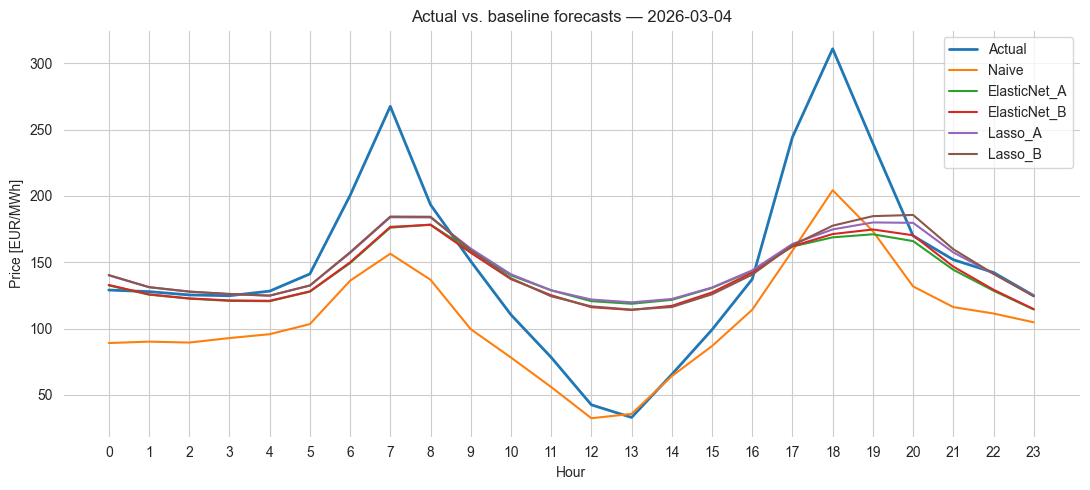

In [234]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and baseline predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test.loc[day].values,
    "naive": Y_test_naive.loc[day].values,
    "ElasticNet_A": Y_test_pred_enet_A.loc[day].values,
    "ElasticNet_B": Y_test_pred_enet_B.loc[day].values,
    "Lasso_A": Y_test_pred_lasso_A.loc[day].values,
    "Lasso_B": Y_test_pred_lasso_B.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and all baseline forecasts
plt.figure(figsize=(11, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["ElasticNet_A"], label="ElasticNet_A")
plt.plot(plot_df["hour"], plot_df["ElasticNet_B"], label="ElasticNet_B")
plt.plot(plot_df["hour"], plot_df["Lasso_A"], label="Lasso_A")
plt.plot(plot_df["hour"], plot_df["Lasso_B"], label="Lasso_B")

# Add labels and formatting
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. baseline forecasts — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------

### 29. Import and set up CatBoost

##### Track A — Cecilia-style selected features, Track B — Full feature set

In [235]:
# Import CatBoostRegressor for tree-based regression
from catboost import CatBoostRegressor

### 30. Build the CatBoost baseline

#### Track A — Cecilia-style selected features

In [236]:
# Build a CatBoost pipeline for Track A
catboost_A = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the CatBoost model on Track A using training data and sample weights
catboost_A.fit(X_train_A, Y_train, sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_cat_A = pd.DataFrame(
    catboost_A.predict(X_val_A),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_cat_A = pd.DataFrame(
    catboost_A.predict(X_test_A),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_cat_A.shape)
print("Test prediction shape:", Y_test_pred_cat_A.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 31. Evaluate the CatBoost baseline

#### Track A — Cecilia-style selected features

In [237]:
# Compute validation metrics for CatBoost Track A
cat_A_val_mae = mae_24(Y_val, Y_val_pred_cat_A)
cat_A_val_dae = dae(Y_val, Y_val_pred_cat_A)
cat_A_val_rmae = rmae(cat_A_val_mae, naive_val_mae)

# Compute test metrics for CatBoost Track A
cat_A_test_mae = mae_24(Y_test, Y_test_pred_cat_A)
cat_A_test_dae = dae(Y_test, Y_test_pred_cat_A)
cat_A_test_rmae = rmae(cat_A_test_mae, naive_test_mae)

# Print validation results
print("CatBoost Track A - validation MAE:", round(cat_A_val_mae, 4))
print("CatBoost Track A - validation DAE:", round(cat_A_val_dae, 4))
print("CatBoost Track A - validation RMAE:", round(cat_A_val_rmae, 4))

# Print test results
print("CatBoost Track A - test MAE:", round(cat_A_test_mae, 4))
print("CatBoost Track A - test DAE:", round(cat_A_test_dae, 4))
print("CatBoost Track A - test RMAE:", round(cat_A_test_rmae, 4))

CatBoost Track A - validation MAE: 23.5567
CatBoost Track A - validation DAE: 14.4854
CatBoost Track A - validation RMAE: 0.829
CatBoost Track A - test MAE: 20.2164
CatBoost Track A - test DAE: 16.194
CatBoost Track A - test RMAE: 0.8659


### 32. Build the CatBoost baseline

#### Track B — Full feature set

In [238]:
# Build a CatBoost model for Track B
catboost_B = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the CatBoost model on Track B using training data and sample weights
catboost_B.fit(X_train_B, Y_train, sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_cat_B = pd.DataFrame(
    catboost_B.predict(X_val_B),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_cat_B = pd.DataFrame(
    catboost_B.predict(X_test_B),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_cat_B.shape)
print("Test prediction shape:", Y_test_pred_cat_B.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 33. Evaluate the CatBoost baseline

#### Track B — Full feature set

In [239]:
# Compute validation metrics for CatBoost Track B
cat_B_val_mae = mae_24(Y_val, Y_val_pred_cat_B)
cat_B_val_dae = dae(Y_val, Y_val_pred_cat_B)
cat_B_val_rmae = rmae(cat_B_val_mae, naive_val_mae)

# Compute test metrics for CatBoost Track B
cat_B_test_mae = mae_24(Y_test, Y_test_pred_cat_B)
cat_B_test_dae = dae(Y_test, Y_test_pred_cat_B)
cat_B_test_rmae = rmae(cat_B_test_mae, naive_test_mae)

# Print validation results
print("CatBoost Track B - validation MAE:", round(cat_B_val_mae, 4))
print("CatBoost Track B - validation DAE:", round(cat_B_val_dae, 4))
print("CatBoost Track B - validation RMAE:", round(cat_B_val_rmae, 4))

# Print test results
print("CatBoost Track B - test MAE:", round(cat_B_test_mae, 4))
print("CatBoost Track B - test DAE:", round(cat_B_test_dae, 4))
print("CatBoost Track B - test RMAE:", round(cat_B_test_rmae, 4))

CatBoost Track B - validation MAE: 23.2045
CatBoost Track B - validation DAE: 14.1037
CatBoost Track B - validation RMAE: 0.8166
CatBoost Track B - test MAE: 20.2838
CatBoost Track B - test DAE: 16.5654
CatBoost Track B - test RMAE: 0.8688


### 33b. Compare all baseline models including CatBoost

In [240]:
# Create a summary table with validation and test results for all current models
results_with_catboost = pd.DataFrame({
    "model": [
        "Naive",
        "ElasticNet_A",
        "ElasticNet_B",
        "Lasso_A",
        "Lasso_B",
        "CatBoost_A",
        "CatBoost_B"
    ],
    "val_MAE": [
        naive_val_mae,
        enet_A_val_mae,
        enet_B_val_mae,
        lasso_A_val_mae,
        lasso_B_val_mae,
        cat_A_val_mae,
        cat_B_val_mae
    ],
    "val_DAE": [
        naive_val_dae,
        enet_A_val_dae,
        enet_B_val_dae,
        lasso_A_val_dae,
        lasso_B_val_dae,
        cat_A_val_dae,
        cat_B_val_dae
    ],
    "val_RMAE": [
        1.0,
        enet_A_val_rmae,
        enet_B_val_rmae,
        lasso_A_val_rmae,
        lasso_B_val_rmae,
        cat_A_val_rmae,
        cat_B_val_rmae
    ],
    "test_MAE": [
        naive_test_mae,
        enet_A_test_mae,
        enet_B_test_mae,
        lasso_A_test_mae,
        lasso_B_test_mae,
        cat_A_test_mae,
        cat_B_test_mae
    ],
    "test_DAE": [
        naive_test_dae,
        enet_A_test_dae,
        enet_B_test_dae,
        lasso_A_test_dae,
        lasso_B_test_dae,
        cat_A_test_dae,
        cat_B_test_dae
    ],
    "test_RMAE": [
        1.0,
        enet_A_test_rmae,
        enet_B_test_rmae,
        lasso_A_test_rmae,
        lasso_B_test_rmae,
        cat_A_test_rmae,
        cat_B_test_rmae
    ]
})

# Sort by validation MAE from best to worst
results_with_catboost = results_with_catboost.sort_values("val_MAE").reset_index(drop=True)

# Round values for cleaner display
results_with_catboost = results_with_catboost.round(4)

# Display the comparison table
display(results_with_catboost)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,Lasso_B,22.2449,15.4270,0.7828,19.2603,13.9575,0.8249
1,Lasso_A,22.7482,15.4737,0.8005,18.7544,13.2057,0.8033
2,ElasticNet_B,23.0225,15.8108,0.8102,19.2775,13.9064,0.8257
3,CatBoost_B,23.2045,14.1037,0.8166,20.2838,16.5654,0.8688
4,ElasticNet_A,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
5,CatBoost_A,23.5567,14.4854,0.8290,20.2164,16.1940,0.8659
6,Naive,28.4164,22.5700,1.0000,23.3474,18.8407,1.0000


### 33c. Plot actual vs. all model forecasts for one example day

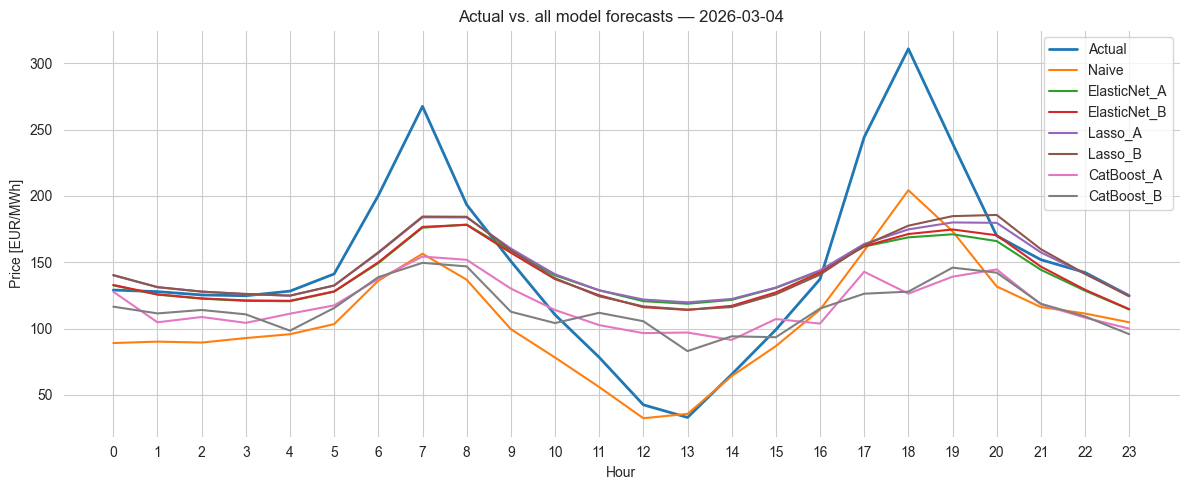

In [241]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and all model predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test.loc[day].values,
    "naive": Y_test_naive.loc[day].values,
    "ElasticNet_A": Y_test_pred_enet_A.loc[day].values,
    "ElasticNet_B": Y_test_pred_enet_B.loc[day].values,
    "Lasso_A": Y_test_pred_lasso_A.loc[day].values,
    "Lasso_B": Y_test_pred_lasso_B.loc[day].values,
    "CatBoost_A": Y_test_pred_cat_A.loc[day].values,
    "CatBoost_B": Y_test_pred_cat_B.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and all model forecasts
plt.figure(figsize=(12, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["ElasticNet_A"], label="ElasticNet_A")
plt.plot(plot_df["hour"], plot_df["ElasticNet_B"], label="ElasticNet_B")
plt.plot(plot_df["hour"], plot_df["Lasso_A"], label="Lasso_A")
plt.plot(plot_df["hour"], plot_df["Lasso_B"], label="Lasso_B")
plt.plot(plot_df["hour"], plot_df["CatBoost_A"], label="CatBoost_A")
plt.plot(plot_df["hour"], plot_df["CatBoost_B"], label="CatBoost_B")

# Add labels and formatting
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. all model forecasts — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### The current CatBoost baseline (sofar)

The current CatBoost setup is already a **multi-output forecast**, because the target matrix has shape \((N, 24)\) and the model is wrapped with `MultiOutputRegressor`. In practice, this means that **24 separate models** are trained, one for each forecast hour. So the model predicts the full next-day price curve, but it does **not** learn the dependencies between the 24 hours jointly.

At this stage, the CatBoost results should be understood as a **first baseline only**. We have not yet applied cross-validation for CatBoost, and we have not tuned its hyperparameters. The current setup therefore serves as an initial benchmark rather than a final optimized model.

A likely reason for the weak performance is the current construction of the daily feature matrix. Right now, the daily input table is based on keeping only the **first hourly row of each day**, which is too limited for predicting the entire 24-hour price curve of the next day. As a result, the model does not receive enough information about the daily shape of load, renewable generation, or price dynamics.

The main issue is therefore likely **feature representation rather than CatBoost itself**. Before tuning the model, the next important step is to build a more suitable daily feature matrix that better matches the forecasting task.

-----------------------------------------------------------------------------------------------------------------

### 34. Define a richer daily feature design 

---------------------------------------------------------------------------------------------------------------------

### Build the richer daily feature matrix

The target of the model is a **24-dimensional daily price vector**, so one row of the input should also describe the forecast day more completely.

For this reason, the daily feature matrix is rebuilt in two parts:

- **daily scalar features**, which appear once per day
- **hourly block features**, which are reshaped into 24 hour-specific columns

This means that instead of keeping only one hourly value per day, the model receives the **full 24-hour profile** of selected inputs such as lagged prices, load, wind, and solar.

This is important because the model is trained for a **multi-output forecast**:
$$
\hat{\mathbf{Y}}_d = \left[\hat{Y}_d^{1}, \hat{Y}_d^{2}, \dots, \hat{Y}_d^{24}\right]
$$

So the input representation should also better reflect the daily structure of the forecasting problem.

### 34. Define the richer daily feature design

In [242]:
# Define hourly features that should enter as 24-hour blocks
hourly_block_features = [
    "price_lag_24h",
    "price_lag_168h",
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "temperature",
    "wind_speed",
    "total_wind_forecast",
    "delta_wind_forecast"
]

# Define daily scalar features that enter once per day
daily_scalar_features = [
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "is_holiday",
    "is_hol_or_week",
    "gas_price",
    "coal_price",
    "co2_price",
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "is_crisis_period",
    "is_high_price_regime"
]

# Show both feature groups
print("Hourly block features:", hourly_block_features)
print("Daily scalar features:", daily_scalar_features)

Hourly block features: ['price_lag_24h', 'price_lag_168h', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'temperature', 'wind_speed', 'total_wind_forecast', 'delta_wind_forecast']
Daily scalar features: ['day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'is_hol_or_week', 'gas_price', 'coal_price', 'co2_price', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_crisis_period', 'is_high_price_regime']


### 35. Construct the richer daily feature matrix


After defining the hourly block features and daily scalar features, the new daily input matrix is constructed.

First, each row is assigned to a forecast day and an hour.  
Then, the hourly block features are reshaped from long hourly format into wide daily format, so that each selected feature contributes 24 hour-specific columns.

At the same time, the daily scalar features are kept once per day.

Finally, both parts are concatenated into a new daily feature matrix:

$$
\mathbf{X}_d = \left[\mathbf{X}_{d,\mathrm{scalar}}, \mathbf{X}_{d,\mathrm{block}}\right]
$$

This yields a richer day-level representation that is better suited for forecasting the 24-hour target vector.

In [243]:
# Create a daily datetime column for grouping
df["forecast_date"] = df["timestamp"].dt.floor("D")

# Recreate the hour column directly from the timestamp
df["hour"] = df["timestamp"].dt.hour

# Reshape the hourly block features into daily wide format
X_blocks = df.pivot(index="forecast_date", columns="hour", values=hourly_block_features)

# Flatten the multi-level column names
X_blocks.columns = [f"{feature}_h{hour:02d}" for feature, hour in X_blocks.columns]

# Keep one row per day for the daily scalar features
X_scalars = df.groupby("forecast_date")[daily_scalar_features].first()

# Combine daily scalar features and hourly block features
X_daily_v2 = pd.concat([X_scalars, X_blocks], axis=1).sort_index()

# Show the result
print("X_daily_v2 shape:", X_daily_v2.shape)
display(X_daily_v2.head())

X_daily_v2 shape: (2606, 260)


,day_of_week,month,year,is_weekend,is_holiday,is_hol_or_week,gas_price,coal_price,co2_price,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,month_sin,month_cos,dow_sin,dow_cos,is_crisis_period,is_high_price_regime,price_lag_24h_h00,price_lag_24h_h01,price_lag_24h_h02,price_lag_24h_h03,price_lag_24h_h04,price_lag_24h_h05,price_lag_24h_h06,price_lag_24h_h07,price_lag_24h_h08,price_lag_24h_h09,price_lag_24h_h10,price_lag_24h_h11,price_lag_24h_h12,price_lag_24h_h13,price_lag_24h_h14,price_lag_24h_h15,price_lag_24h_h16,price_lag_24h_h17,price_lag_24h_h18,price_lag_24h_h19,price_lag_24h_h20,price_lag_24h_h21,price_lag_24h_h22,price_lag_24h_h23,price_lag_168h_h00,price_lag_168h_h01,price_lag_168h_h02,price_lag_168h_h03,price_lag_168h_h04,price_lag_168h_h05,price_lag_168h_h06,price_lag_168h_h07,price_lag_168h_h08,price_lag_168h_h09,price_lag_168h_h10,price_lag_168h_h11,price_lag_168h_h12,price_lag_168h_h13,price_lag_168h_h14,price_lag_168h_h15,price_lag_168h_h16,price_lag_168h_h17,price_lag_168h_h18,price_lag_168h_h19,price_lag_168h_h20,price_lag_168h_h21,price_lag_168h_h22,price_lag_168h_h23,load_h00,load_h01,load_h02,load_h03,load_h04,load_h05,load_h06,load_h07,load_h08,load_h09,load_h10,load_h11,load_h12,load_h13,load_h14,load_h15,load_h16,load_h17,load_h18,load_h19,load_h20,load_h21,load_h22,load_h23,wind_offshore_h00,wind_offshore_h01,wind_offshore_h02,wind_offshore_h03,wind_offshore_h04,wind_offshore_h05,wind_offshore_h06,wind_offshore_h07,wind_offshore_h08,wind_offshore_h09,wind_offshore_h10,wind_offshore_h11,wind_offshore_h12,wind_offshore_h13,wind_offshore_h14,wind_offshore_h15,wind_offshore_h16,wind_offshore_h17,wind_offshore_h18,wind_offshore_h19,wind_offshore_h20,wind_offshore_h21,wind_offshore_h22,wind_offshore_h23,wind_onshore_h00,wind_onshore_h01,wind_onshore_h02,wind_onshore_h03,wind_onshore_h04,wind_onshore_h05,wind_onshore_h06,wind_onshore_h07,wind_onshore_h08,wind_onshore_h09,wind_onshore_h10,wind_onshore_h11,wind_onshore_h12,wind_onshore_h13,wind_onshore_h14,wind_onshore_h15,wind_onshore_h16,wind_onshore_h17,wind_onshore_h18,wind_onshore_h19,wind_onshore_h20,wind_onshore_h21,wind_onshore_h22,wind_onshore_h23,solar_h00,solar_h01,solar_h02,solar_h03,solar_h04,solar_h05,solar_h06,solar_h07,solar_h08,solar_h09,solar_h10,solar_h11,solar_h12,solar_h13,solar_h14,solar_h15,solar_h16,solar_h17,solar_h18,solar_h19,solar_h20,solar_h21,solar_h22,solar_h23,temperature_h00,temperature_h01,temperature_h02,temperature_h03,temperature_h04,temperature_h05,temperature_h06,temperature_h07,temperature_h08,temperature_h09,temperature_h10,temperature_h11,temperature_h12,temperature_h13,temperature_h14,temperature_h15,temperature_h16,temperature_h17,temperature_h18,temperature_h19,temperature_h20,temperature_h21,temperature_h22,temperature_h23,wind_speed_h00,wind_speed_h01,wind_speed_h02,wind_speed_h03,wind_speed_h04,wind_speed_h05,wind_speed_h06,wind_speed_h07,wind_speed_h08,wind_speed_h09,wind_speed_h10,wind_speed_h11,wind_speed_h12,wind_speed_h13,wind_speed_h14,wind_speed_h15,wind_speed_h16,wind_speed_h17,wind_speed_h18,wind_speed_h19,wind_speed_h20,wind_speed_h21,wind_speed_h22,wind_speed_h23,total_wind_forecast_h00,total_wind_forecast_h01,total_wind_forecast_h02,total_wind_forecast_h03,total_wind_forecast_h04,total_wind_forecast_h05,total_wind_forecast_h06,total_wind_forecast_h07,total_wind_forecast_h08,total_wind_forecast_h09,total_wind_forecast_h10,total_wind_forecast_h11,total_wind_forecast_h12,total_wind_forecast_h13,total_wind_forecast_h14,total_wind_forecast_h15,total_wind_forecast_h16,total_wind_forecast_h17,total_wind_forecast_h18,total_wind_forecast_h19,total_wind_forecast_h20,total_wind_forecast_h21,total_wind_forecast_h22,total_wind_forecast_h23,delta_wind_forecast_h00,delta_wind_forecast_h01,delta_wind_forecast_h02,delta_wind_forecast_h03,delta_wind_forecast_h04,delta_wind_forecast_h05,delta_wind_forecast_h06,delta_wind_forecast_h07,delta_wind_forecast_h08,delta_wind_forecast_

### 36. Align the richer daily feature matrix with the target matrix

In [244]:
# Keep only dates that exist in both the richer feature matrix and the target matrix
common_dates_v2 = X_daily_v2.index.intersection(Y_daily.index)

# Align the richer feature matrix and the target matrix to the same dates
X_daily_v2 = X_daily_v2.loc[common_dates_v2].sort_index()
Y_daily_v2 = Y_daily.loc[common_dates_v2].sort_index()

# Check the final shapes
print("X_daily_v2 shape:", X_daily_v2.shape)
print("Y_daily_v2 shape:", Y_daily_v2.shape)

# Check whether both indices are identical
print("Indices match:", X_daily_v2.index.equals(Y_daily_v2.index))

X_daily_v2 shape: (2606, 260)
Y_daily_v2 shape: (2606, 24)
Indices match: True


### 37. Split test/train: Create the chronological split for the richer daily feature matrix

In [245]:
# Split the richer feature matrix into train, validation, and test sets
X_train_v2 = X_daily_v2[X_daily_v2.index < "2025-01-01"].copy()
X_val_v2 = X_daily_v2[(X_daily_v2.index >= "2025-01-01") & (X_daily_v2.index < "2025-07-01")].copy()
X_test_v2 = X_daily_v2[X_daily_v2.index >= "2025-07-01"].copy()

# Split the aligned target matrix into train, validation, and test sets
Y_train_v2 = Y_daily_v2[Y_daily_v2.index < "2025-01-01"].copy()
Y_val_v2 = Y_daily_v2[(Y_daily_v2.index >= "2025-01-01") & (Y_daily_v2.index < "2025-07-01")].copy()
Y_test_v2 = Y_daily_v2[Y_daily_v2.index >= "2025-07-01"].copy()

# Show the resulting shapes
print("X_train_v2:", X_train_v2.shape)
print("X_val_v2:", X_val_v2.shape)
print("X_test_v2:", X_test_v2.shape)

print("Y_train_v2:", Y_train_v2.shape)
print("Y_val_v2:", Y_val_v2.shape)
print("Y_test_v2:", Y_test_v2.shape)

X_train_v2: (2177, 260)
X_val_v2: (181, 260)
X_test_v2: (248, 260)
Y_train_v2: (2177, 24)
Y_val_v2: (181, 24)
Y_test_v2: (248, 24)


### 38. Create training sample weights for the richer daily feature matrix

In [246]:
# Create a weight series with default weight 1.0 for all training days
train_weights_v2 = pd.Series(1.0, index=X_train_v2.index)

# Downweight the pre-crisis period
train_weights_v2.loc[(train_weights_v2.index >= "2019-01-01") & (train_weights_v2.index < "2021-01-01")] = 0.6

# Downweight the crisis period more strongly
train_weights_v2.loc[(train_weights_v2.index >= "2021-01-01") & (train_weights_v2.index < "2023-01-01")] = 0.3

# Keep full weight for the post-crisis period inside training
train_weights_v2.loc[(train_weights_v2.index >= "2023-01-01") & (train_weights_v2.index < "2025-01-01")] = 1.0

# Show how many days fall into each weight group
display(train_weights_v2.value_counts().sort_index())

# Show the first rows
display(train_weights_v2.head())

0.3    730
0.6    716
1.0    731
Name: count, dtype: int64

forecast_date
2019-01-16    0.6
2019-01-17    0.6
2019-01-18    0.6
2019-01-19    0.6
2019-01-20    0.6
dtype: float64

### 39. Build the ElasticNet baseline with the richer daily feature matrix

In [247]:
# Build a pipeline with feature scaling and ElasticNet
elasticnet_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42)
    ))
])

# Fit the ElasticNet model on the richer daily feature matrix using training data and sample weights
elasticnet_v2.fit(X_train_v2, Y_train_v2, model__sample_weight=train_weights_v2)

# Predict on the validation set
Y_val_pred_enet_v2 = pd.DataFrame(
    elasticnet_v2.predict(X_val_v2),
    index=Y_val_v2.index,
    columns=Y_val_v2.columns
)

# Predict on the test set
Y_test_pred_enet_v2 = pd.DataFrame(
    elasticnet_v2.predict(X_test_v2),
    index=Y_test_v2.index,
    columns=Y_test_v2.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_enet_v2.shape)
print("Test prediction shape:", Y_test_pred_enet_v2.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 40. Evaluate the ElasticNet baseline with the richer daily feature matrix

In [248]:
# Compute validation metrics for ElasticNet with the richer daily feature matrix
enet_v2_val_mae = mae_24(Y_val_v2, Y_val_pred_enet_v2)
enet_v2_val_dae = dae(Y_val_v2, Y_val_pred_enet_v2)
enet_v2_val_rmae = rmae(enet_v2_val_mae, naive_val_mae)

# Compute test metrics for ElasticNet with the richer daily feature matrix
enet_v2_test_mae = mae_24(Y_test_v2, Y_test_pred_enet_v2)
enet_v2_test_dae = dae(Y_test_v2, Y_test_pred_enet_v2)
enet_v2_test_rmae = rmae(enet_v2_test_mae, naive_test_mae)

# Print validation results
print("ElasticNet v2 - validation MAE:", round(enet_v2_val_mae, 4))
print("ElasticNet v2 - validation DAE:", round(enet_v2_val_dae, 4))
print("ElasticNet v2 - validation RMAE:", round(enet_v2_val_rmae, 4))

# Print test results
print("ElasticNet v2 - test MAE:", round(enet_v2_test_mae, 4))
print("ElasticNet v2 - test DAE:", round(enet_v2_test_dae, 4))
print("ElasticNet v2 - test RMAE:", round(enet_v2_test_rmae, 4))

ElasticNet v2 - validation MAE: 13.749
ElasticNet v2 - validation DAE: 8.5325
ElasticNet v2 - validation RMAE: 0.4838
ElasticNet v2 - test MAE: 13.2919
ElasticNet v2 - test DAE: 8.1573
ElasticNet v2 - test RMAE: 0.5693


### 41. Compare ElasticNet with the old and richer daily feature matrix

In [249]:
# Create a comparison table for the old and richer ElasticNet setups
results_enet_compare = pd.DataFrame({
    "model": ["ElasticNet_old", "ElasticNet_v2"],
    "val_MAE": [enet_A_val_mae, enet_v2_val_mae],
    "val_DAE": [enet_A_val_dae, enet_v2_val_dae],
    "val_RMAE": [enet_A_val_rmae, enet_v2_val_rmae],
    "test_MAE": [enet_A_test_mae, enet_v2_test_mae],
    "test_DAE": [enet_A_test_dae, enet_v2_test_dae],
    "test_RMAE": [enet_A_test_rmae, enet_v2_test_rmae]
})

# Round values for cleaner display
results_enet_compare = results_enet_compare.round(4)

# Display the comparison
display(results_enet_compare)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,ElasticNet_old,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
1,ElasticNet_v2,13.7490,8.5325,0.4838,13.2919,8.1573,0.5693


### 41b. Plot actual vs. ElasticNet v2 forecast for one example day

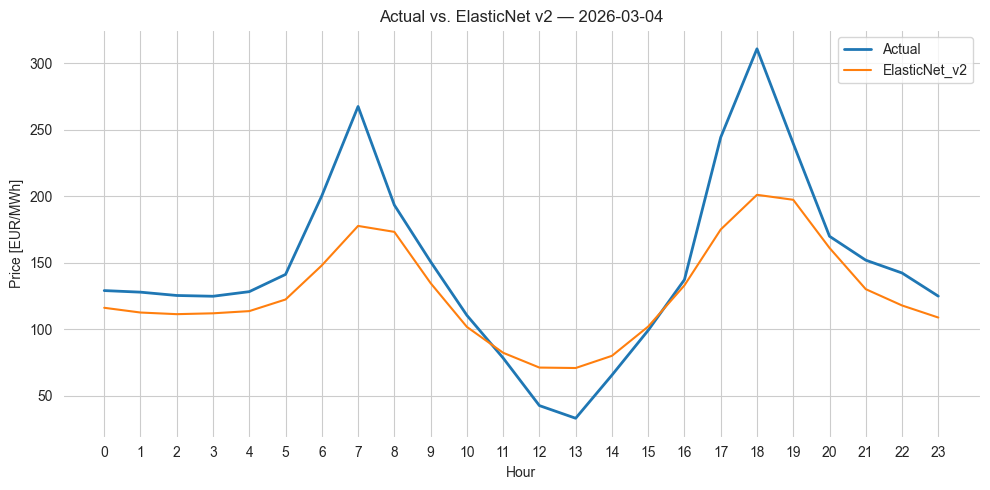

In [250]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and ElasticNet v2 predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test_v2.loc[day].values,
    "ElasticNet_v2": Y_test_pred_enet_v2.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and ElasticNet v2 forecast
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["ElasticNet_v2"], label="ElasticNet_v2")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. ElasticNet v2 — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 42. Build the CatBoost baseline with the richer daily feature matrix

In [251]:
# Build a CatBoost model for the richer daily feature matrix
catboost_v2 = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the CatBoost model on the richer daily feature matrix using training data and sample weights
catboost_v2.fit(X_train_v2, Y_train_v2, sample_weight=train_weights_v2)

# Predict on the validation set
Y_val_pred_cat_v2 = pd.DataFrame(
    catboost_v2.predict(X_val_v2),
    index=Y_val_v2.index,
    columns=Y_val_v2.columns
)

# Predict on the test set
Y_test_pred_cat_v2 = pd.DataFrame(
    catboost_v2.predict(X_test_v2),
    index=Y_test_v2.index,
    columns=Y_test_v2.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_cat_v2.shape)
print("Test prediction shape:", Y_test_pred_cat_v2.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 43. Evaluate the CatBoost baseline with the richer daily feature matrix

In [252]:
# Compute validation metrics for CatBoost with the richer daily feature matrix
cat_v2_val_mae = mae_24(Y_val_v2, Y_val_pred_cat_v2)
cat_v2_val_dae = dae(Y_val_v2, Y_val_pred_cat_v2)
cat_v2_val_rmae = rmae(cat_v2_val_mae, naive_val_mae)

# Compute test metrics for CatBoost with the richer daily feature matrix
cat_v2_test_mae = mae_24(Y_test_v2, Y_test_pred_cat_v2)
cat_v2_test_dae = dae(Y_test_v2, Y_test_pred_cat_v2)
cat_v2_test_rmae = rmae(cat_v2_test_mae, naive_test_mae)

# Print validation results
print("CatBoost v2 - validation MAE:", round(cat_v2_val_mae, 4))
print("CatBoost v2 - validation DAE:", round(cat_v2_val_dae, 4))
print("CatBoost v2 - validation RMAE:", round(cat_v2_val_rmae, 4))

# Print test results
print("CatBoost v2 - test MAE:", round(cat_v2_test_mae, 4))
print("CatBoost v2 - test DAE:", round(cat_v2_test_dae, 4))
print("CatBoost v2 - test RMAE:", round(cat_v2_test_rmae, 4))

CatBoost v2 - validation MAE: 14.9323
CatBoost v2 - validation DAE: 8.0562
CatBoost v2 - validation RMAE: 0.5255
CatBoost v2 - test MAE: 13.1067
CatBoost v2 - test DAE: 8.5366
CatBoost v2 - test RMAE: 0.5614


### 44. Compare the old and richer feature-matrix setups

In [253]:
# Create a summary table comparing old vs v2 for ElasticNet and CatBoost
results_v2_compare = pd.DataFrame({
    "model": ["ElasticNet_old", "ElasticNet_v2", "CatBoost_old", "CatBoost_v2"],
    "val_MAE": [enet_A_val_mae, enet_v2_val_mae, cat_A_val_mae, cat_v2_val_mae],
    "val_DAE": [enet_A_val_dae, enet_v2_val_dae, cat_A_val_dae, cat_v2_val_dae],
    "val_RMAE": [enet_A_val_rmae, enet_v2_val_rmae, cat_A_val_rmae, cat_v2_val_rmae],
    "test_MAE": [enet_A_test_mae, enet_v2_test_mae, cat_A_test_mae, cat_v2_test_mae],
    "test_DAE": [enet_A_test_dae, enet_v2_test_dae, cat_A_test_dae, cat_v2_test_dae],
    "test_RMAE": [enet_A_test_rmae, enet_v2_test_rmae, cat_A_test_rmae, cat_v2_test_rmae]
})

# Round values for cleaner display
results_v2_compare = results_v2_compare.round(4)

# Display the comparison table
display(results_v2_compare)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,ElasticNet_old,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
1,ElasticNet_v2,13.7490,8.5325,0.4838,13.2919,8.1573,0.5693
2,CatBoost_old,23.5567,14.4854,0.8290,20.2164,16.1940,0.8659
3,CatBoost_v2,14.9323,8.0562,0.5255,13.1067,8.5366,0.5614


### 44b. Plot old vs. richer setup for one example day

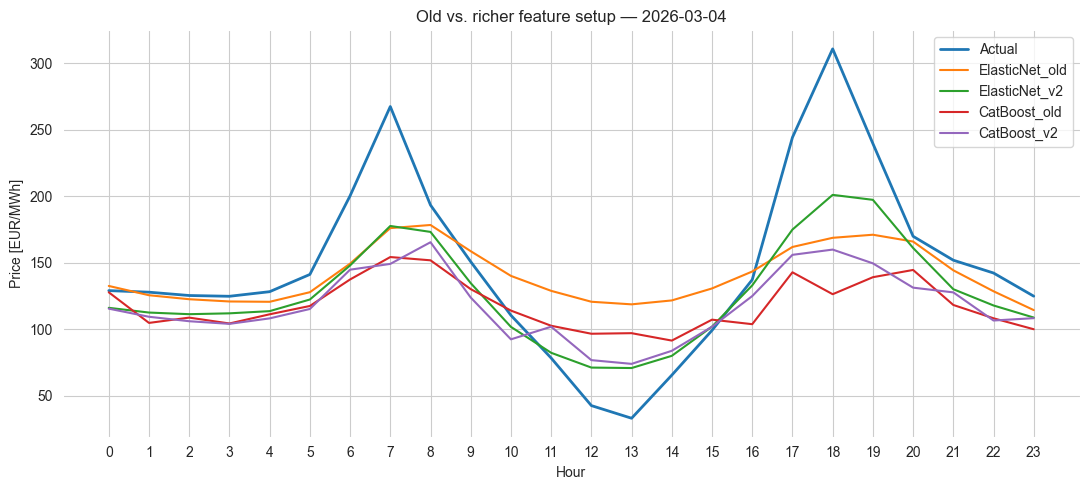

In [254]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and old/v2 model predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test_v2.loc[day].values,
    "ElasticNet_old": Y_test_pred_enet_A.loc[day].values,
    "ElasticNet_v2": Y_test_pred_enet_v2.loc[day].values,
    "CatBoost_old": Y_test_pred_cat_A.loc[day].values,
    "CatBoost_v2": Y_test_pred_cat_v2.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and old/v2 model forecasts
plt.figure(figsize=(11, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["ElasticNet_old"], label="ElasticNet_old")
plt.plot(plot_df["hour"], plot_df["ElasticNet_v2"], label="ElasticNet_v2")
plt.plot(plot_df["hour"], plot_df["CatBoost_old"], label="CatBoost_old")
plt.plot(plot_df["hour"], plot_df["CatBoost_v2"], label="CatBoost_v2")

# Add labels and formatting
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Old vs. richer feature setup — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 45a. Check the richer daily feature matrix before CatBoost tuning

In [256]:
# Check data types in the richer training feature matrix
display(X_train_v2.dtypes.value_counts())

# Check missing values per column
missing_v2 = X_train_v2.isna().sum().sort_values(ascending=False)

# Show only columns with missing values
display(missing_v2[missing_v2 > 0].head(20))

# Check whether the target has missing values
print("Missing values in Y_train_v2:", Y_train_v2.isna().sum().sum())

float64    257
bool         3
Name: count, dtype: int64

Series([], dtype: int64)

Missing values in Y_train_v2: 0


### 45. Simple hyperparameter tuning for CatBoost with error handling

In [257]:
# Define a small grid of CatBoost hyperparameters
depth_grid = [4, 6, 8]
learning_rate_grid = [0.03, 0.05, 0.1]
iterations_grid = [200, 300, 500]

# Store successful results
tuning_results_cat_v2 = []

# Loop over all parameter combinations
for depth in depth_grid:
    for learning_rate in learning_rate_grid:
        for iterations in iterations_grid:
            try:
                # Print the current combination
                print(f"Running depth={depth}, learning_rate={learning_rate}, iterations={iterations}")

                # Build the CatBoost model
                model = MultiOutputRegressor(
                    CatBoostRegressor(
                        iterations=iterations,
                        depth=depth,
                        learning_rate=learning_rate,
                        loss_function="MAE",
                        eval_metric="MAE",
                        verbose=0,
                        random_state=42
                    )
                )

                # Fit the model
                model.fit(X_train_v2, Y_train_v2, sample_weight=train_weights_v2)

                # Predict on validation data
                Y_val_pred = pd.DataFrame(
                    model.predict(X_val_v2),
                    index=Y_val_v2.index,
                    columns=Y_val_v2.columns
                )

                # Compute validation metrics
                val_mae = mae_24(Y_val_v2, Y_val_pred)
                val_dae = dae(Y_val_v2, Y_val_pred)
                val_rmae = rmae(val_mae, naive_val_mae)

                # Store the result
                tuning_results_cat_v2.append({
                    "depth": depth,
                    "learning_rate": learning_rate,
                    "iterations": iterations,
                    "val_MAE": val_mae,
                    "val_DAE": val_dae,
                    "val_RMAE": val_rmae
                })

            except Exception as e:
                print(f"FAILED: depth={depth}, learning_rate={learning_rate}, iterations={iterations}")
                print(repr(e))

# Convert results to a DataFrame
tuning_results_cat_v2 = pd.DataFrame(tuning_results_cat_v2)

# Sort by validation MAE
tuning_results_cat_v2 = tuning_results_cat_v2.sort_values("val_MAE").reset_index(drop=True)

# Show the best combinations
display(tuning_results_cat_v2.head(10).round(4))

Running depth=4, learning_rate=0.03, iterations=200
Running depth=4, learning_rate=0.03, iterations=300
Running depth=4, learning_rate=0.03, iterations=500
FAILED: depth=4, learning_rate=0.03, iterations=500
CatBoostError()
Running depth=4, learning_rate=0.05, iterations=200
Running depth=4, learning_rate=0.05, iterations=300
Running depth=4, learning_rate=0.05, iterations=500
Running depth=4, learning_rate=0.1, iterations=200
Running depth=4, learning_rate=0.1, iterations=300
FAILED: depth=4, learning_rate=0.1, iterations=300
CatBoostError()
Running depth=4, learning_rate=0.1, iterations=500
Running depth=6, learning_rate=0.03, iterations=200
Running depth=6, learning_rate=0.03, iterations=300
Running depth=6, learning_rate=0.03, iterations=500
Running depth=6, learning_rate=0.05, iterations=200
FAILED: depth=6, learning_rate=0.05, iterations=200
CatBoostError()
Running depth=6, learning_rate=0.05, iterations=300
Running depth=6, learning_rate=0.05, iterations=500
Running depth=6, lea

,depth,learning_rate,iterations,val_MAE,val_DAE,val_RMAE
0,6,0.03,500,14.7123,8.0042,0.5177
1,8,0.03,500,14.7449,8.2105,0.5189
2,6,0.05,500,14.7729,7.9890,0.5199
3,4,0.05,500,14.9084,7.7871,0.5246
4,6,0.05,300,14.9323,8.0562,0.5255
5,8,0.05,500,14.9977,8.1994,0.5278
6,8,0.05,300,15.0221,8.1637,0.5286
7,8,0.03,300,15.0550,8.4031,0.5298
8,6,0.03,300,15.1395,8.2793,0.5328
9,8,0.05,200,15.1729,8.2556,0.5340


### 46. Refit the best CatBoost model

In [258]:
# Set the best CatBoost hyperparameters from the tuning results
best_depth = 6
best_learning_rate = 0.03
best_iterations = 500

# Build the tuned CatBoost model
catboost_v2_tuned = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=best_iterations,
        depth=best_depth,
        learning_rate=best_learning_rate,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the tuned CatBoost model on the richer daily feature matrix
catboost_v2_tuned.fit(X_train_v2, Y_train_v2, sample_weight=train_weights_v2)

# Predict on the validation set
Y_val_pred_cat_v2_tuned = pd.DataFrame(
    catboost_v2_tuned.predict(X_val_v2),
    index=Y_val_v2.index,
    columns=Y_val_v2.columns
)

# Predict on the test set
Y_test_pred_cat_v2_tuned = pd.DataFrame(
    catboost_v2_tuned.predict(X_test_v2),
    index=Y_test_v2.index,
    columns=Y_test_v2.columns
)

### 47. Evaluate the tuned CatBoost model

In [259]:
# Compute validation metrics for the tuned CatBoost model
cat_v2_tuned_val_mae = mae_24(Y_val_v2, Y_val_pred_cat_v2_tuned)
cat_v2_tuned_val_dae = dae(Y_val_v2, Y_val_pred_cat_v2_tuned)
cat_v2_tuned_val_rmae = rmae(cat_v2_tuned_val_mae, naive_val_mae)

# Compute test metrics for the tuned CatBoost model
cat_v2_tuned_test_mae = mae_24(Y_test_v2, Y_test_pred_cat_v2_tuned)
cat_v2_tuned_test_dae = dae(Y_test_v2, Y_test_pred_cat_v2_tuned)
cat_v2_tuned_test_rmae = rmae(cat_v2_tuned_test_mae, naive_test_mae)

# Print validation results
print("CatBoost v2 tuned - validation MAE:", round(cat_v2_tuned_val_mae, 4))
print("CatBoost v2 tuned - validation DAE:", round(cat_v2_tuned_val_dae, 4))
print("CatBoost v2 tuned - validation RMAE:", round(cat_v2_tuned_val_rmae, 4))

# Print test results
print("CatBoost v2 tuned - test MAE:", round(cat_v2_tuned_test_mae, 4))
print("CatBoost v2 tuned - test DAE:", round(cat_v2_tuned_test_dae, 4))
print("CatBoost v2 tuned - test RMAE:", round(cat_v2_tuned_test_rmae, 4))

CatBoost v2 tuned - validation MAE: 14.7123
CatBoost v2 tuned - validation DAE: 8.0042
CatBoost v2 tuned - validation RMAE: 0.5177
CatBoost v2 tuned - test MAE: 12.8601
CatBoost v2 tuned - test DAE: 8.3403
CatBoost v2 tuned - test RMAE: 0.5508


### 48. Final comparison of all model variants

In [260]:
# Create a final comparison table for all main model variants
results_final = pd.DataFrame({
    "model": [
        "Naive",
        "ElasticNet_V1_TrackA",
        "ElasticNet_V1_TrackB",
        "Lasso_V1_TrackA",
        "Lasso_V1_TrackB",
        "CatBoost_V1_TrackA",
        "CatBoost_V1_TrackB",
        "ElasticNet_V2_Untuned",
        "CatBoost_V2_Untuned",
        "CatBoost_V2_Tuned"
    ],
    "val_MAE": [
        naive_val_mae,
        enet_A_val_mae,
        enet_B_val_mae,
        lasso_A_val_mae,
        lasso_B_val_mae,
        cat_A_val_mae,
        cat_B_val_mae,
        enet_v2_val_mae,
        cat_v2_val_mae,
        cat_v2_tuned_val_mae
    ],
    "val_DAE": [
        naive_val_dae,
        enet_A_val_dae,
        enet_B_val_dae,
        lasso_A_val_dae,
        lasso_B_val_dae,
        cat_A_val_dae,
        cat_B_val_dae,
        enet_v2_val_dae,
        cat_v2_val_dae,
        cat_v2_tuned_val_dae
    ],
    "val_RMAE": [
        1.0,
        enet_A_val_rmae,
        enet_B_val_rmae,
        lasso_A_val_rmae,
        lasso_B_val_rmae,
        cat_A_val_rmae,
        cat_B_val_rmae,
        enet_v2_val_rmae,
        cat_v2_val_rmae,
        cat_v2_tuned_val_rmae
    ],
    "test_MAE": [
        naive_test_mae,
        enet_A_test_mae,
        enet_B_test_mae,
        lasso_A_test_mae,
        lasso_B_test_mae,
        cat_A_test_mae,
        cat_B_test_mae,
        enet_v2_test_mae,
        cat_v2_test_mae,
        cat_v2_tuned_test_mae
    ],
    "test_DAE": [
        naive_test_dae,
        enet_A_test_dae,
        enet_B_test_dae,
        lasso_A_test_dae,
        lasso_B_test_dae,
        cat_A_test_dae,
        cat_B_test_dae,
        enet_v2_test_dae,
        cat_v2_test_dae,
        cat_v2_tuned_test_dae
    ],
    "test_RMAE": [
        1.0,
        enet_A_test_rmae,
        enet_B_test_rmae,
        lasso_A_test_rmae,
        lasso_B_test_rmae,
        cat_A_test_rmae,
        cat_B_test_rmae,
        enet_v2_test_rmae,
        cat_v2_test_rmae,
        cat_v2_tuned_test_rmae
    ]
})

# Sort the table by validation MAE from best to worst
results_final = results_final.sort_values("val_MAE").reset_index(drop=True)

# Round values for cleaner display
results_final = results_final.round(4)

# Display the final comparison table
display(results_final)

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,ElasticNet_V2_Untuned,13.7490,8.5325,0.4838,13.2919,8.1573,0.5693
1,CatBoost_V2_Tuned,14.7123,8.0042,0.5177,12.8601,8.3403,0.5508
2,CatBoost_V2_Untuned,14.9323,8.0562,0.5255,13.1067,8.5366,0.5614
3,Lasso_V1_TrackB,22.2449,15.4270,0.7828,19.2603,13.9575,0.8249
4,Lasso_V1_TrackA,22.7482,15.4737,0.8005,18.7544,13.2057,0.8033
5,ElasticNet_V1_TrackB,23.0225,15.8108,0.8102,19.2775,13.9064,0.8257
6,CatBoost_V1_TrackB,23.2045,14.1037,0.8166,20.2838,16.5654,0.8688
7,ElasticNet_V1_TrackA,23.5289,15.9263,0.8280,19.3831,13.7867,0.8302
8,CatBoost_V1_TrackA,23.5567,14.4854,0.8290,20.2164,16.1940,0.8659
9,Naive,28.4164,22.5700,1.0000,23.3474,18.8407,1.0000


### 49. Plot the final shortlisted forecasts for one example day

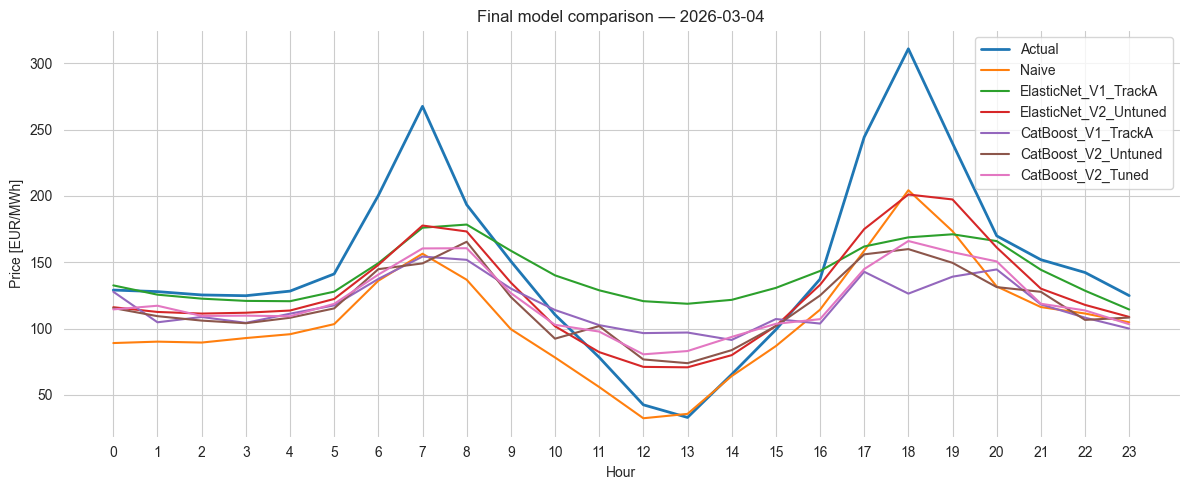

In [261]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and selected model predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test_v2.loc[day].values,
    "naive": Y_test_naive.loc[day].values,
    "ElasticNet_V1_TrackA": Y_test_pred_enet_A.loc[day].values,
    "ElasticNet_V2_Untuned": Y_test_pred_enet_v2.loc[day].values,
    "CatBoost_V1_TrackA": Y_test_pred_cat_A.loc[day].values,
    "CatBoost_V2_Untuned": Y_test_pred_cat_v2.loc[day].values,
    "CatBoost_V2_Tuned": Y_test_pred_cat_v2_tuned.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and selected model forecasts
plt.figure(figsize=(12, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["ElasticNet_V1_TrackA"], label="ElasticNet_V1_TrackA")
plt.plot(plot_df["hour"], plot_df["ElasticNet_V2_Untuned"], label="ElasticNet_V2_Untuned")
plt.plot(plot_df["hour"], plot_df["CatBoost_V1_TrackA"], label="CatBoost_V1_TrackA")
plt.plot(plot_df["hour"], plot_df["CatBoost_V2_Untuned"], label="CatBoost_V2_Untuned")
plt.plot(plot_df["hour"], plot_df["CatBoost_V2_Tuned"], label="CatBoost_V2_Tuned")

# Add labels and formatting
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Final model comparison — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()